# Tutorial 1 Exercise Solutions

This concise, standalone notebook provides complete solutions for Exercises E.1–E.3. It uses **simulated P, Q and voltage data only**; no real customer measurements are included.

- E.1: blocked three-fold ranges and scaling checks;
- E.2: four configurations across three folds, giving 12 training runs; and
- E.3: seeds 0, 1 and 2 followed by one final test evaluation.

The test voltage targets are used only after the configuration and seed have been selected. A full CPU run may take several minutes.


## 1. Initialisation and Simulated Data

Import the required packages, load the four simulated-data files and verify the training and test shapes.


In [1]:
from pathlib import Path
import itertools
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

WORKING_DIRECTORY = Path.cwd()
DATASET_NAME = "synthentic_data_5_min_LV"
DATA_DIRECTORY = WORKING_DIRECTORY / DATASET_NAME

data_files = {
    "PQ_tr": DATA_DIRECTORY / "training" / "PQ.pkl",
    "V_tr": DATA_DIRECTORY / "training" / "V.pkl",
    "PQ_te": DATA_DIRECTORY / "test" / "PQ.pkl",
    "V_te": DATA_DIRECTORY / "test" / "V.pkl",
}

missing = [path for path in data_files.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing simulated-data files:\n"
        + "\n".join(f"  - {path}" for path in missing)
    )

PQ_tr = pd.read_pickle(data_files["PQ_tr"]).to_numpy(np.float32)
V_tr = pd.read_pickle(data_files["V_tr"]).to_numpy(np.float32)
PQ_te = pd.read_pickle(data_files["PQ_te"]).to_numpy(np.float32)
V_te = pd.read_pickle(data_files["V_te"]).to_numpy(np.float32)

assert PQ_tr.shape == (6048, 62)
assert V_tr.shape == (6048, 31)
assert PQ_te.shape == (2016, 62)
assert V_te.shape == (2016, 31)
assert all(np.isfinite(array).all() for array in [PQ_tr, V_tr, PQ_te, V_te])

C = V_tr.shape[1]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))

print("Working folder: repository root")
print(f"Simulated-data folder: {DATA_DIRECTORY.name}")
print(f"Device: {DEVICE}")
print(f"Training shapes: PQ={PQ_tr.shape}, V={V_tr.shape}")
print(f"Test shapes: PQ={PQ_te.shape}, V={V_te.shape}")

Working folder: repository root
Simulated-data folder: synthentic_data_5_min_LV
Device: cpu
Training shapes: PQ=(6048, 62), V=(6048, 31)
Test shapes: PQ=(2016, 62), V=(2016, 31)


## 2. Shared Functions

Define the blocked K-fold split, neural network, fixed-epoch training, unscaled prediction and three-fold RMSE evaluation functions. Each fold fits its scalers using only that fold's training blocks.


In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def blocked_kfold_indices(n_instances, k=3):
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


class NNi(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_neurons, activation):
        super().__init__()
        activations = {"tanh": nn.Tanh, "relu": nn.ReLU}
        if activation not in activations:
            raise ValueError(f"Unsupported activation: {activation}")

        self.network = nn.Sequential(
            nn.Linear(in_dim, hidden_neurons),
            activations[activation](),
            nn.Linear(hidden_neurons, out_dim),
        )

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, inputs):
        return self.network(inputs)


def train_fixed(model, X_train, Y_train, lr, weight_decay, batch_size, epochs):
    dataset = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(Y_train),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = model.to(DEVICE)
    optimiser = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)
            optimiser.zero_grad()
            loss = loss_fn(model(X_batch), Y_batch)
            loss.backward()
            optimiser.step()
    return model


def predict_unscaled(model, X_scaled, output_scaler):
    model.eval()
    with torch.inference_mode():
        scaled = model(torch.from_numpy(X_scaled).to(DEVICE)).cpu().numpy()
    return output_scaler.inverse_transform(scaled)


def evaluate_config(config, PQ, V, k=3, base_seed=42):
    fold_rmse = []
    start_time = time.time()

    for fold_number, (train_idx, val_idx) in enumerate(
        blocked_kfold_indices(len(PQ), k), start=1
    ):
        PQ_fold_train, PQ_fold_val = PQ[train_idx], PQ[val_idx]
        V_fold_train, V_fold_val = V[train_idx], V[val_idx]

        input_scaler = MinMaxScaler().fit(PQ_fold_train)
        output_scaler = MinMaxScaler().fit(V_fold_train)

        X_train = input_scaler.transform(PQ_fold_train).astype(np.float32)
        Y_train = output_scaler.transform(V_fold_train).astype(np.float32)
        X_val = input_scaler.transform(PQ_fold_val).astype(np.float32)

        # The same fold seed is used for every configuration for a fair comparison.
        set_seed(base_seed + fold_number)
        model = NNi(
            in_dim=X_train.shape[1],
            out_dim=Y_train.shape[1],
            hidden_neurons=config["hidden_neurons"],
            activation=config["activation"],
        )
        model = train_fixed(
            model,
            X_train,
            Y_train,
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            batch_size=config["batch_size"],
            epochs=config["epochs"],
        )

        V_val_estimated = predict_unscaled(model, X_val, output_scaler)
        rmse = float(np.sqrt(np.mean((V_fold_val - V_val_estimated) ** 2)))
        fold_rmse.append(rmse)

    return {
        **config,
        "fold_1_RMSE": fold_rmse[0],
        "fold_2_RMSE": fold_rmse[1],
        "fold_3_RMSE": fold_rmse[2],
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
        "train_time_s": float(time.time() - start_time),
    }

## 3. E.1: Blocked Folds and Scaling

Report the three validation ranges and check whether validation values fall outside `[0,1]` after the MinMax scalers are fitted only on the training blocks.


In [3]:
fold_rows = []
range_rows = []

for fold_number, (train_idx, val_idx) in enumerate(
    blocked_kfold_indices(len(PQ_tr), k=3), start=1
):
    fold_rows.append(
        {
            "fold": fold_number,
            "training instances": len(train_idx),
            "validation instances": len(val_idx),
            "validation range (0-based)": f"{val_idx[0]}–{val_idx[-1]}",
            "validation range (1-based)": f"{val_idx[0] + 1}–{val_idx[-1] + 1}",
        }
    )

    input_scaler = MinMaxScaler().fit(PQ_tr[train_idx])
    output_scaler = MinMaxScaler().fit(V_tr[train_idx])
    X_val = input_scaler.transform(PQ_tr[val_idx])
    Y_val = output_scaler.transform(V_tr[val_idx])

    for name, values in [("P/Q inputs", X_val), ("voltage targets", Y_val)]:
        below = int((values < 0).sum())
        above = int((values > 1).sum())
        range_rows.append(
            {
                "fold": fold_number,
                "values": name,
                "minimum": float(values.min()),
                "maximum": float(values.max()),
                "count below 0": below,
                "count above 1": above,
                "out-of-range percent": 100 * (below + above) / values.size,
            }
        )

fold_summary = pd.DataFrame(fold_rows)
range_summary = pd.DataFrame(range_rows)

print("Three blocked validation folds:")
display(fold_summary)
print("Validation values after training-only MinMax scaling:")
display(range_summary.round(6))

Three blocked validation folds:


,fold,training instances,validation instances,validation range (0-based),validation range (1-based)
0,1,4032,2016,0–2015,1–2016
1,2,4032,2016,2016–4031,2017–4032
2,3,4032,2016,4032–6047,4033–6048


Validation values after training-only MinMax scaling:


,fold,values,minimum,maximum,count below 0,count above 1,out-of-range percent
0,1,P/Q inputs,-0.366800,2.227198,102,84,0.148810
1,1,voltage targets,-0.577530,1.084961,216,106,0.515233
2,2,P/Q inputs,-0.327235,2.590898,46,65,0.088806
3,2,voltage targets,-0.748421,1.114944,181,72,0.404826
4,3,P/Q inputs,-0.794376,2.070529,65,141,0.164811
5,3,voltage targets,-0.149384,1.100224,16,49,0.104007


### E.1 Answer

- The validation ranges are **1–2,016**, **2,017–4,032** and **4,033–6,048**. Each fold uses 4,032 instances for training and 2,016 for validation.
- Adjacent five-minute samples are usually similar. Random shuffling could place nearly adjacent samples in training and validation, making the validation error too optimistic. Consecutive blocks avoid this problem.
- About **0.089%–0.165%** of validation P/Q values and **0.104%–0.515%** of voltage targets are outside `[0,1]`. This is expected when a validation block extends beyond the training block's minimum or maximum. The scaler must not be refitted on validation data.


## 4. E.2: Compare `tanh` and `relu`

With learning rate `1e-3`, L2 weight decay `1e-5`, batch size 72 and 300 epochs, compare:

| Hidden neurons | Activation |
|---:|:---:|
| 93 | `tanh` |
| 155 | `tanh` |
| 93 | `relu` |
| 155 | `relu` |

Rank the configurations by mean three-fold validation RMSE without using the test period.


In [4]:
exercise_configs = [
    {
        "hidden_neurons": hidden_neurons,
        "activation": activation,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "batch_size": 72,
        "epochs": 300,
    }
    for hidden_neurons, activation in itertools.product(
        [93, 155], ["tanh", "relu"]
    )
]

exercise_rows = []
for number, config in enumerate(exercise_configs, start=1):
    result = evaluate_config(config, PQ_tr, V_tr, k=3, base_seed=42)
    exercise_rows.append(result)
    print(
        f"Configuration {number}/4: hidden={config['hidden_neurons']}, "
        f"activation={config['activation']}, "
        f"mean RMSE={result['RMSE_kfold']:.6f} V"
    )

exercise_results = (
    pd.DataFrame(exercise_rows)
    .sort_values("RMSE_kfold")
    .reset_index(drop=True)
)

result_columns = [
    "hidden_neurons",
    "activation",
    "fold_1_RMSE",
    "fold_2_RMSE",
    "fold_3_RMSE",
    "RMSE_kfold",
    "RMSE_std",
    "train_time_s",
]

print("\nE.2 ranking (lower mean RMSE is better):")
display(exercise_results[result_columns].round(6))

best_exercise_config = exercise_results.iloc[0].to_dict()
print("Selected E.2 configuration:")
print(f"  hidden neurons: {int(best_exercise_config['hidden_neurons'])}")
print(f"  activation: {best_exercise_config['activation']}")
print(f"  mean three-fold RMSE: {best_exercise_config['RMSE_kfold']:.6f} V")

Configuration 1/4: hidden=93, activation=tanh, mean RMSE=0.013553 V


Configuration 2/4: hidden=93, activation=relu, mean RMSE=0.018688 V


Configuration 3/4: hidden=155, activation=tanh, mean RMSE=0.013845 V


Configuration 4/4: hidden=155, activation=relu, mean RMSE=0.023858 V

E.2 ranking (lower mean RMSE is better):


,hidden_neurons,activation,fold_1_RMSE,fold_2_RMSE,fold_3_RMSE,RMSE_kfold,RMSE_std,train_time_s
0,93,tanh,0.015423,0.013046,0.012188,0.013553,0.001369,111.205827
1,155,tanh,0.014628,0.013516,0.013392,0.013845,0.000556,120.795732
2,93,relu,0.022369,0.015801,0.017895,0.018688,0.002740,192.365422
3,155,relu,0.027570,0.024583,0.019419,0.023858,0.003367,261.693851


Selected E.2 configuration:
  hidden neurons: 93
  activation: tanh
  mean three-fold RMSE: 0.013553 V


### E.2 Answer

The best configuration is **93 hidden neurons + `tanh`**, with a mean three-fold RMSE of **0.013553 V**. The results for 155 + `tanh`, 93 + `relu` and 155 + `relu` are `0.013845 V`, `0.018688 V` and `0.023858 V`, respectively.

Although 155 + `tanh` varies less between folds, 93 + `tanh` has the lowest mean RMSE and is selected. Test voltage targets were not used.


## 5. E.3: Random Seeds and Final Test

Using the best E.2 configuration and the complete training period, train seeds 0, 1 and 2. Select the seed by training RMSE, then use the held-out test targets for the first time.


In [5]:
input_scaler_full = MinMaxScaler().fit(PQ_tr)
output_scaler_full = MinMaxScaler().fit(V_tr)

X_train_full = input_scaler_full.transform(PQ_tr).astype(np.float32)
Y_train_full = output_scaler_full.transform(V_tr).astype(np.float32)
X_test_full = input_scaler_full.transform(PQ_te).astype(np.float32)

final_hidden = int(best_exercise_config["hidden_neurons"])
final_activation = str(best_exercise_config["activation"])
final_lr = 1e-3
final_weight_decay = 1e-5
final_batch_size = 72
final_epochs = 300

seed_rows = []
seed_models = {}

for seed in [0, 1, 2]:
    set_seed(seed)
    model = NNi(
        in_dim=X_train_full.shape[1],
        out_dim=Y_train_full.shape[1],
        hidden_neurons=final_hidden,
        activation=final_activation,
    )
    start_time = time.time()
    model = train_fixed(
        model,
        X_train_full,
        Y_train_full,
        lr=final_lr,
        weight_decay=final_weight_decay,
        batch_size=final_batch_size,
        epochs=final_epochs,
    )
    elapsed = time.time() - start_time

    V_train_estimated = predict_unscaled(
        model, X_train_full, output_scaler_full
    )
    train_rmse = float(
        np.sqrt(np.mean((V_tr - V_train_estimated) ** 2))
    )
    seed_rows.append(
        {
            "seed": seed,
            "train_RMSE": train_rmse,
            "training_time_s": elapsed,
        }
    )
    seed_models[seed] = model
    print(f"Seed {seed}: training RMSE={train_rmse:.6f} V")

seed_results = (
    pd.DataFrame(seed_rows)
    .sort_values("train_RMSE")
    .reset_index(drop=True)
)
selected_seed = int(seed_results.iloc[0]["seed"])
exercise_final_model = seed_models[selected_seed]

print("\nSeed ranking (test targets were not used):")
display(seed_results.round(6))
print(f"Selected seed: {selected_seed}")

Seed 0: training RMSE=0.013591 V


Seed 1: training RMSE=0.018023 V


Seed 2: training RMSE=0.011305 V

Seed ranking (test targets were not used):


,seed,train_RMSE,training_time_s
0,2,0.011305,48.177202
1,0,0.013591,49.490348
2,1,0.018023,48.430166


Selected seed: 2


In [6]:
# The held-out test voltage targets are used here for the first time.
V_test_estimated = predict_unscaled(
    exercise_final_model, X_test_full, output_scaler_full
)
test_error = V_test_estimated - V_te

test_rmse = float(np.sqrt(np.mean(test_error ** 2)))
test_mae = float(np.mean(np.abs(test_error)))
test_max_error = float(np.max(np.abs(test_error)))
per_customer_rmse = np.sqrt(np.mean(test_error ** 2, axis=0))
worst_customer = int(np.argmax(per_customer_rmse))
worst_error = test_error[:, worst_customer]
worst_bias = float(np.mean(worst_error))
worst_mae = float(np.mean(np.abs(worst_error)))
worst_p95 = float(np.percentile(np.abs(worst_error), 95))
worst_max = float(np.max(np.abs(worst_error)))

REFERENCE_TEST_RMSE = 0.012346
difference = test_rmse - REFERENCE_TEST_RMSE

metrics = pd.DataFrame(
    {
        "metric": [
            "Overall test RMSE (V)",
            "Overall test MAE (V)",
            "Maximum absolute error (V)",
            "Worst customer (1-based)",
            "Worst-customer RMSE (V)",
            "Worst-customer mean bias (V)",
            "Worst-customer 95th abs. error (V)",
            "Worst-customer maximum abs. error (V)",
        ],
        "value": [
            test_rmse,
            test_mae,
            test_max_error,
            worst_customer + 1,
            per_customer_rmse[worst_customer],
            worst_bias,
            worst_p95,
            worst_max,
        ],
    }
)
display(metrics.round(6))

comparison_word = "higher" if difference > 0 else "lower"
print(
    f"The exercise-model test RMSE is {abs(difference):.6f} V "
    f"{comparison_word} than the tutorial benchmark ({REFERENCE_TEST_RMSE:.6f} V)."
)
print(f"Worst customer: C{worst_customer + 1}")

,metric,value
0,Overall test RMSE (V),0.014368
1,Overall test MAE (V),0.009569
2,Maximum absolute error (V),0.189774
3,Worst customer (1-based),24.000000
4,Worst-customer RMSE (V),0.026134
5,Worst-customer mean bias (V),0.004543
6,Worst-customer 95th abs. error (V),0.054424
7,Worst-customer maximum abs. error (V),0.189774


The exercise-model test RMSE is 0.002022 V higher than the tutorial benchmark (0.012346 V).
Worst customer: C24


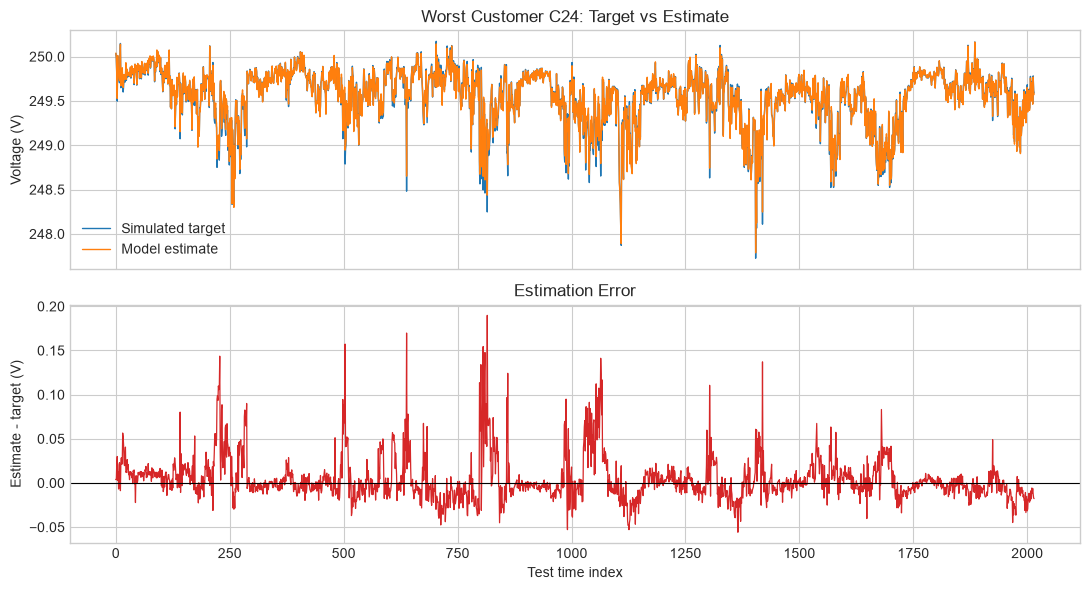

In [7]:
time_index = np.arange(len(V_te))
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(
    time_index,
    V_te[:, worst_customer],
    label="Simulated target",
    linewidth=1.0,
)
axes[0].plot(
    time_index,
    V_test_estimated[:, worst_customer],
    label="Model estimate",
    linewidth=1.0,
)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(
    f"Worst Customer C{worst_customer + 1}: Target vs Estimate"
)
axes[0].legend()

axes[1].plot(time_index, worst_error, color="tab:red", linewidth=0.9)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Test time index")
axes[1].set_ylabel("Estimate - target (V)")
axes[1].set_title("Estimation Error")

plt.tight_layout()
plt.show()

### E.3 Answer

- Seeds 0, 1 and 2 produce training RMSE values of `0.013591 V`, `0.018023 V` and `0.011305 V`; therefore **seed 2** is selected.
- Final test RMSE is **0.014368 V** and MAE is **0.009569 V**. The RMSE is about **16.4%** higher than the tutorial benchmark of `0.012346 V`; the exercise model uses only 300 epochs, so lower accuracy is reasonable.
- The worst simulated customer is **C24**, with RMSE `0.026134 V`. Errors show a small positive bias and several local periods and spikes, but no severe one-direction bias across the complete test period.

These conclusions apply only to this fixed simulated feeder and exercise setup.
